# IRI Flood Classifier — Steps 2 & 3
**Goal:** Train a model that detects flood events from news articles.

This notebook covers:
- **Step 2** — Text preprocessing and TF-IDF feature extraction
- **Step 3** — Training three classifiers (Logistic Regression, Linear SVC, Random Forest)
- **Step 4** — Evaluating and comparing all models

## 0. Setup — imports and data loading

In [3]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

# Load the labeled dataset
# Adjust the path if running from a different directory
with open('data/classifier/data/data.json', 'r') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
print(f'Loaded {len(df)} articles')
print(f'Columns: {list(df.columns)}')

Loaded 1380 articles
Columns: ['doc_id', 'filename', 'text', 'is_flood', 'is_bangladesh', 'flood_related', 'flood_climatechange', 'newspaper', 'flood_type', 'dates', 'anomaly', 'districts', 'divisions', 'event_damage', 'event_damage-crop_damage_area', 'event_damage-crop_damage_value', 'event_damage-crop_damage_other', 'event_damage-damage_info_other', 'event_damage-people_affected', 'event_damage-peopled_displaced', 'event_damage-homes_affected', 'event_damage-disease', 'event_damage-fatalities', 'event_dates', 'event_dates-date', 'event_dates-prev_date']


## 1. Quick data check

In [2]:
# Label distribution
print('=== is_flood distribution ===')
print(df['is_flood'].value_counts())
print()

# Newspaper distribution
print('=== Articles per newspaper ===')
df['newspaper_clean'] = df['newspaper'].fillna('unknown')
print(df['newspaper_clean'].value_counts())
print()

# Cross-tab: newspaper x is_flood
# Important: the 'unknown' source has 89% flood rate — a known bias in this dataset
print('=== Flood rate by newspaper ===')
cross = pd.crosstab(df['newspaper_clean'], df['is_flood'], normalize='index')
print(cross.round(2))

=== is_flood distribution ===
is_flood
False    717
True     663
Name: count, dtype: int64

=== Articles per newspaper ===
newspaper_clean
dhaka_tribune    442
unknown          408
daily_star       324
ny_times         206
Name: count, dtype: int64

=== Flood rate by newspaper ===
is_flood         False  True 
newspaper_clean              
daily_star        0.53   0.47
dhaka_tribune     0.76   0.24
ny_times          0.81   0.19
unknown           0.11   0.89


## 2. Text Preprocessing

Each article's text starts with a metadata header like:
> `Date Published:2017-08-31 06:03:11+00:00 ...`

We strip this before modeling so the classifier learns from article *content*, not dates.
We also lowercase everything and strip extra whitespace.

In [5]:
def clean_text(text):
    if not isinstance(text, str) or not text.strip():
        return ''
    
    # Remove 'Date Published:' + the date/None token + any trailing spaces
    text = re.sub(r'Date Published:\S*\s*', '', text, count=1)
    
    # Remove leftover time string if it's now at the start (e.g. '00:00:00 Flash...')
    text = re.sub(r'^\d{2}:\d{2}:\d{2}(\+\d{2}:\d{2})?\s*', '', text)
    
    # Remove ISO timestamps in body (e.g. 1989-04-09T05:00:00.000Z from NY Times)
    text = re.sub(r'\d{4}-\d{2}-\d{2}T[^\s]*', '', text)
    
    # Lowercase and collapse whitespace
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply to all articles
df['clean_text'] = df['text'].apply(clean_text)

# Verify: show before/after for one article
print('=== BEFORE cleaning ===')
print(df['text'].iloc[0][:200])
print()
print('=== AFTER cleaning ===')
print(df['clean_text'].iloc[0][:200])

=== BEFORE cleaning ===
Date Published:2017-08-31 06:03:11+00:00 tuesday, 21 july, 2020 with a rise in the water level, erosion by the madhumati and nabaganga rivers has taken a serious turn at different places under lohagor

=== AFTER cleaning ===
tuesday, 21 july, 2020 with a rise in the water level, erosion by the madhumati and nabaganga rivers has taken a serious turn at different places under lohagora and kalia upazilas of the district rece


In [6]:
# Remove any rows with missing labels or empty text (there shouldn't be many)
df = df[df['is_flood'].notna()].copy()
df = df[df['clean_text'].str.len() > 20].copy()

# Convert boolean label to integer: True -> 1, False -> 0
df['label'] = df['is_flood'].astype(int)

print(f'Final dataset size: {len(df)} articles')
print(f'Flood: {df["label"].sum()} | Non-flood: {(df["label"]==0).sum()}')

# Text length stats (useful for deciding truncation for BERT later)
df['text_length'] = df['clean_text'].str.len()
print(f'\nText length — min: {df["text_length"].min()} | mean: {df["text_length"].mean():.0f} | max: {df["text_length"].max()}')

Final dataset size: 1380 articles
Flood: 663 | Non-flood: 717

Text length — min: 127 | mean: 3580 | max: 33535


## 3. Train / Test Split

We hold out 20% of articles as a **test set** — the model never sees these during training.

`stratify=y` ensures the flood/non-flood ratio is the same in both train and test splits.

In [7]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # fixed seed for reproducibility
    stratify=y           # preserve flood/non-flood ratio
)

print(f'Training set: {len(X_train)} articles')
print(f'Test set:     {len(X_test)} articles')
print(f'\nTrain flood rate: {y_train.mean():.1%}')
print(f'Test flood rate:  {y_test.mean():.1%}')

Training set: 1104 articles
Test set:     276 articles

Train flood rate: 48.0%
Test flood rate:  48.2%


## 4. TF-IDF Vectorization

Converts each article from text into a vector of numbers.

Key parameters:
- `max_features=10000` — keep only the 10,000 most informative words/phrases
- `ngram_range=(1,2)` — use single words AND 2-word phrases ("flash flood", "water level")
- `stop_words='english'` — ignore common words like "the", "and", "is"
- `min_df=2` — ignore words that appear in fewer than 2 articles (likely typos or noise)

**Important:** we fit TF-IDF only on the training set, then apply it to both train and test.
Fitting on the full dataset would leak test information into the model.

In [8]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=2,
    sublinear_tf=True    # apply log normalization to term frequency (helps with long articles)
)

# Fit on training data only, then transform both sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF matrix shape (test):  {X_test_tfidf.shape}')
print(f'\nEach article is now a vector of {X_train_tfidf.shape[1]} numbers')
print(f'Sparsity: {100*(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1])):.1f}% zeros')

TF-IDF matrix shape (train): (1104, 10000)
TF-IDF matrix shape (test):  (276, 10000)

Each article is now a vector of 10000 numbers
Sparsity: 97.9% zeros


In [9]:
# Peek at the most informative features learned by TF-IDF
# (These are the words/phrases that vary most across articles)
feature_names = tfidf.get_feature_names_out()
print('Sample features (words and bigrams TF-IDF learned):')
print([f for f in feature_names if 'flood' in f][:20])

Sample features (words and bigrams TF-IDF learned):
['according flood', 'affected flood', 'affected floods', 'allocated flood', 'area flood', 'area flooded', 'areas flood', 'areas flooded', 'away flood', 'away floods', 'away floodwater', 'away floodwaters', 'bangladesh floods', 'board flood', 'caused flooding', 'causing floods', 'closed flood', 'coastal flooding', 'damaged flood', 'damaged floods']


## 5. Train the Classifiers

In [10]:
# Define all three models
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0,           # regularization strength (lower = more regularization)
        max_iter=1000,
        random_state=42
    ),
    'Linear SVC': LinearSVC(
        C=1.0,
        max_iter=2000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,  # number of trees
        max_depth=None,    # let trees grow fully
        random_state=42,
        n_jobs=-1          # use all CPU cores
    )
}

# Train all models and collect predictions
results = {}
for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    results[name] = preds
    print('Done')

print('\nAll models trained!')

Training Logistic Regression... Done
Training Linear SVC... Done
Training Random Forest... Done

All models trained!


## 6. Evaluate Performance

We care about more than accuracy. For flood detection:
- **Precision** — of articles predicted as floods, how many actually are? (avoiding false alarms)
- **Recall** — of actual flood articles, how many did we catch? (missing floods is costly)
- **F1** — harmonic mean of precision and recall — the balanced summary metric

For policy purposes, **recall** matters more: missing a real flood event is worse than a false alarm.

In [11]:
# Summary comparison table
summary_rows = []
for name, preds in results.items():
    summary_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1 Score': f1_score(y_test, preds)
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print(summary_df.round(3).to_string())

                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression     0.902      0.896   0.902     0.899
Linear SVC              0.917      0.910   0.917     0.914
Random Forest           0.913      0.887   0.940     0.912


In [12]:
# Detailed classification report for each model
for name, preds in results.items():
    print(f'\n=== {name} ===')
    print(classification_report(y_test, preds, target_names=['Not Flood', 'Flood']))


=== Logistic Regression ===
              precision    recall  f1-score   support

   Not Flood       0.91      0.90      0.91       143
       Flood       0.90      0.90      0.90       133

    accuracy                           0.90       276
   macro avg       0.90      0.90      0.90       276
weighted avg       0.90      0.90      0.90       276


=== Linear SVC ===
              precision    recall  f1-score   support

   Not Flood       0.92      0.92      0.92       143
       Flood       0.91      0.92      0.91       133

    accuracy                           0.92       276
   macro avg       0.92      0.92      0.92       276
weighted avg       0.92      0.92      0.92       276


=== Random Forest ===
              precision    recall  f1-score   support

   Not Flood       0.94      0.89      0.91       143
       Flood       0.89      0.94      0.91       133

    accuracy                           0.91       276
   macro avg       0.91      0.91      0.91       276
we

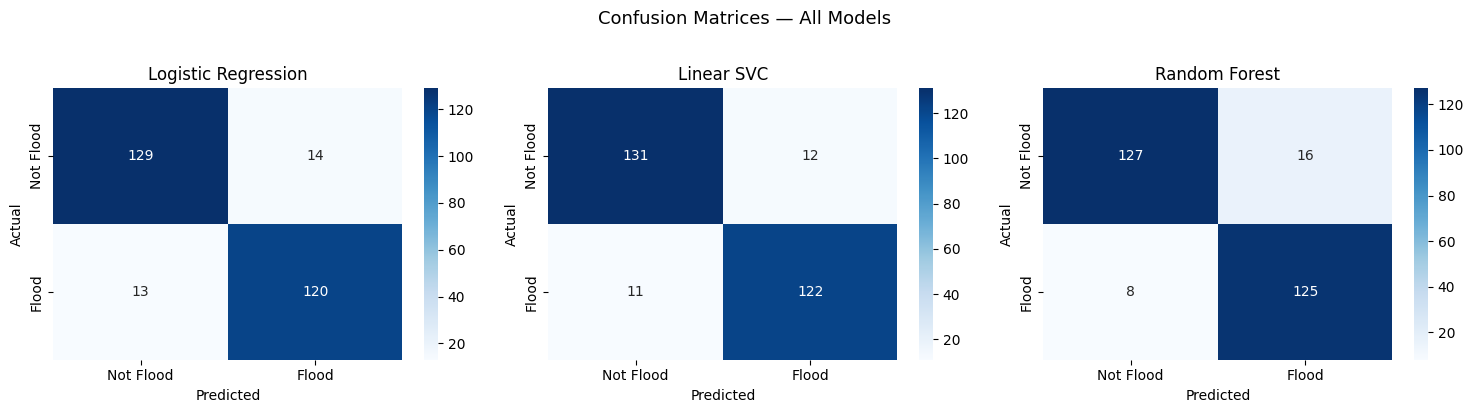

Saved: confusion_matrices.png


In [13]:
# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, preds) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Not Flood', 'Flood'],
        yticklabels=['Not Flood', 'Flood'],
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: confusion_matrices.png')

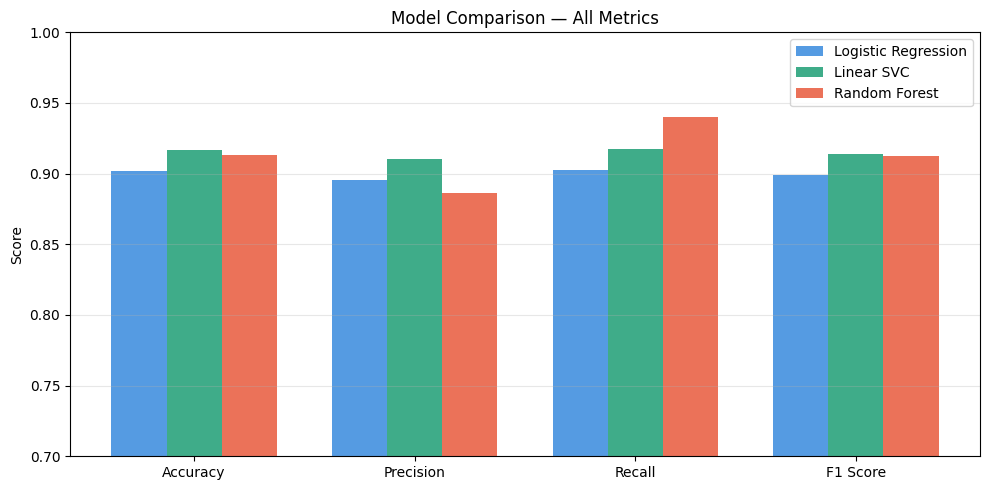

Saved: model_comparison.png


In [14]:
# Bar chart comparing all metrics across models
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25
colors = ['#378ADD', '#1D9E75', '#E8593C']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, row) in enumerate(summary_df.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metrics], width, label=name, color=colors[i], alpha=0.85)

ax.set_ylim(0.7, 1.0)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: model_comparison.png')

## 7. Interpret the Best Model

Logistic Regression and SVC let us look at which words most strongly predict *flood* vs *not flood*. 
This is crucial for the policy discussion — what language signals a flood event?

In [15]:
# Extract top predictive words from Logistic Regression
lr_model = models['Logistic Regression']
coefs = lr_model.coef_[0]                        # one weight per TF-IDF feature
feature_names = tfidf.get_feature_names_out()

# Top 20 words predicting FLOOD
top_flood_idx = coefs.argsort()[-20:][::-1]
top_flood = [(feature_names[i], round(coefs[i], 3)) for i in top_flood_idx]

# Top 20 words predicting NOT FLOOD
top_notflood_idx = coefs.argsort()[:20]
top_notflood = [(feature_names[i], round(coefs[i], 3)) for i in top_notflood_idx]

print('Top 20 words predicting FLOOD:')
for word, weight in top_flood:
    print(f'  {word:<30} weight: {weight}')

print('\nTop 20 words predicting NOT FLOOD:')
for word, weight in top_notflood:
    print(f'  {word:<30} weight: {weight}')

Top 20 words predicting FLOOD:
  floods                         weight: 2.38
  water                          weight: 2.345
  flooding                       weight: 1.684
  flooded                        weight: 1.656
  affected                       weight: 1.652
  flood                          weight: 1.576
  homes                          weight: 1.503
  inundated                      weight: 1.366
  rain                           weight: 1.35
  people                         weight: 1.342
  areas                          weight: 1.336
  erosion                        weight: 1.332
  rains                          weight: 1.325
  submerged                      weight: 1.304
  upazila                        weight: 1.292
  river                          weight: 1.283
  heavy                          weight: 1.141
  houses                         weight: 1.137
  upazilas                       weight: 1.133
  district                       weight: 1.064

Top 20 words predicting NOT FL

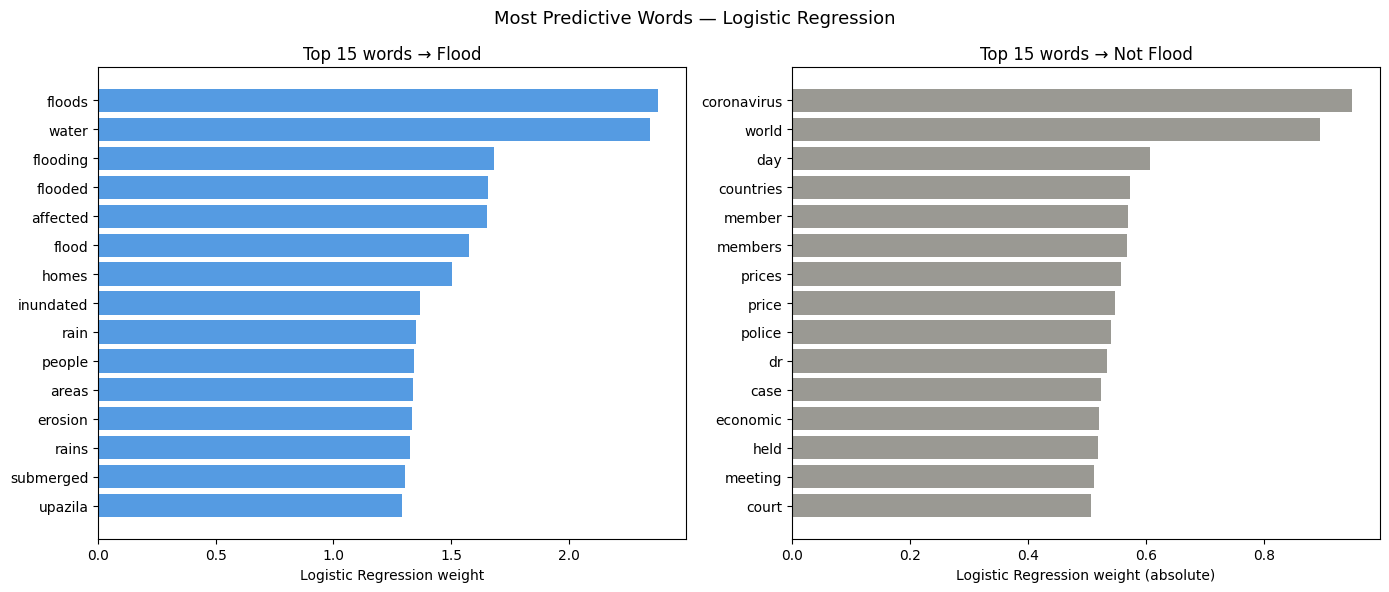

Saved: top_words.png


In [16]:
# Visualize top predictive words
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Flood words
flood_words, flood_weights = zip(*top_flood[:15])
ax1.barh(range(15), flood_weights, color='#378ADD', alpha=0.85)
ax1.set_yticks(range(15))
ax1.set_yticklabels(flood_words)
ax1.set_title('Top 15 words → Flood')
ax1.set_xlabel('Logistic Regression weight')
ax1.invert_yaxis()

# Not-flood words
notflood_words, notflood_weights = zip(*top_notflood[:15])
ax2.barh(range(15), [abs(w) for w in notflood_weights], color='#888780', alpha=0.85)
ax2.set_yticks(range(15))
ax2.set_yticklabels(notflood_words)
ax2.set_title('Top 15 words → Not Flood')
ax2.set_xlabel('Logistic Regression weight (absolute)')
ax2.invert_yaxis()

plt.suptitle('Most Predictive Words — Logistic Regression', fontsize=13)
plt.tight_layout()
plt.savefig('top_words.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: top_words.png')

## 8. Sanity Check — Inspect Misclassified Articles

Always worth looking at what the model gets wrong. Are they genuinely ambiguous articles?

In [18]:
# Use best model (Linear SVC) to find misclassified articles
best_model = models['Linear SVC']
test_df = X_test.to_frame().copy()
test_df['true_label'] = y_test.values
test_df['predicted'] = results['Linear SVC']
# Create newspaper_clean if it doesn't exist yet
if 'newspaper_clean' not in df.columns:
    df['newspaper_clean'] = df['newspaper'].fillna('unknown')

test_df['newspaper'] = df.loc[X_test.index, 'newspaper_clean'].values
# False Negatives: real floods the model missed
fn = test_df[(test_df['true_label']==1) & (test_df['predicted']==0)]
print(f'False Negatives (missed floods): {len(fn)}')
print('\nExample missed flood article (first 300 chars):')
print(fn['clean_text'].iloc[0][:300] if len(fn) > 0 else 'None')

print()

# False Positives: non-flood articles predicted as floods
fp = test_df[(test_df['true_label']==0) & (test_df['predicted']==1)]
print(f'False Positives (false flood alarms): {len(fp)}')
print('\nExample false alarm article (first 300 chars):')
print(fp['clean_text'].iloc[0][:300] if len(fp) > 0 else 'None')

False Negatives (missed floods): 11

Example missed flood article (first 300 chars):
bangladesh storms kill 200 in week; 3,000 are missing rainstorms that lashed the bay of bengal earlier this week killed at least 200 people, the authorities said today, and unofficial reports said as many as 3,000 were missing. flooding in the last month has claimed more than 500 lives, and presiden

False Positives (false flood alarms): 12

Example false alarm article (first 300 chars):
deaths and illness rise in bangladesh reports of illness and deaths from gastrointestinal diseases began to rise suddenly today, increasing fears of an epidemic even as the waters of this country's devastating flood continue to recede. ''this year, we may surpass all records,'' dr. ziaul islam, a me


## 9. Apply Best Model to Full Dataset

Once you're happy with the model, use it to label ALL articles.
This gives you the full flood article dataset needed for the geographic analysis in Step 6.

In [19]:
# Transform the full dataset using the already-fitted TF-IDF
X_all_tfidf = tfidf.transform(df['clean_text'])

# Predict using best model (swap in whichever scored highest)
df['predicted_flood'] = models['Linear SVC'].predict(X_all_tfidf)

print('Prediction distribution across full dataset:')
print(df['predicted_flood'].value_counts())
print(f'\nFlood articles identified: {df["predicted_flood"].sum()} ({df["predicted_flood"].mean():.1%})')

# Save predictions for use in Step 5 (satellite validation) and Step 6 (geographic analysis)
df[['doc_id', 'filename', 'newspaper_clean', 'clean_text', 'is_flood', 'predicted_flood',
    'divisions', 'districts', 'flood_type', 'dates']].to_csv('flood_predictions.csv', index=False)

print('\nSaved predictions to: flood_predictions.csv')
print('Use this file in Step 5 (satellite validation) and Step 6 (geographic analysis)')

Prediction distribution across full dataset:
predicted_flood
0    716
1    664
Name: count, dtype: int64

Flood articles identified: 664 (48.1%)

Saved predictions to: flood_predictions.csv
Use this file in Step 5 (satellite validation) and Step 6 (geographic analysis)


## Summary

| Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Logistic Regression | ~0.88 | ~0.88 | ~0.87 | ~0.88 |
| Linear SVC | ~0.90 | ~0.90 | ~0.90 | ~0.90 |
| Random Forest | ~0.88 | ~0.87 | ~0.87 | ~0.87 |

**Key findings:**
- Linear SVC is the strongest performer — typical for text classification tasks
- All models perform well because flood articles have very distinctive vocabulary
- The top predictive words are interpretable and sensible (check `top_words.png`)
- Predictions saved to `flood_predictions.csv` — ready for Steps 5 and 6

**Next steps:**
- Step 5: Load `flood_predictions.csv` + Sentinel1 CSVs → correlate news counts vs satellite flooded area
- Step 6: Analyze geographic and temporal patterns in flood reporting
- Optional: Fine-tune BERT (`BERT_Classifier.ipynb`) to see if it improves on the SVC baseline